Financial data ingestion

In [2]:
import yfinance as yf
import pandas as pd
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
ticker_symbol = "RELIANCE.NS"
# ticker_symbol = "BHARTIARTL.NS"
# ticker_symbol = "AAPL"

if os.path.exists("stock_data.csv"):
    df = pd.read_csv("stock_data.csv", index_col=0, parse_dates=True)
else:
    print("Downloading data")
    df = yf.download(ticker_symbol, period="5y")
    df.columns = df.columns.get_level_values(0)
    df.to_csv("stock_data.csv")

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-03-16,952.477722,963.994887,950.165234,958.553686,13873801
2021-03-17,931.959900,953.565909,922.777892,951.321425,19210236
2021-03-18,910.988770,945.313525,907.315966,939.917660,20647480
2021-03-19,944.043945,950.323980,899.063583,902.781722,41787429
2021-03-22,935.156616,940.416414,921.916449,939.056159,18572478


In [5]:
df = df.sort_index()
df['SMA'] = df['Close'].rolling(window=50).mean()
df.head()

Price,Close,High,Low,Open,Volume,SMA
Date,,,,,,
2021-03-16,952.477722,963.994887,950.165234,958.553686,13873801,NaN
2021-03-17,931.959900,953.565909,922.777892,951.321425,19210236,NaN
2021-03-18,910.988770,945.313525,907.315966,939.917660,20647480,NaN
2021-03-19,944.043945,950.323980,899.063583,902.781722,41787429,NaN
2021-03-22,935.156616,940.416414,921.916449,939.056159,18572478,NaN


In [6]:
df.dropna(inplace=True)

df['Error'] = df['Close'] - df['SMA']
df['Percentage'] = df['Error'].abs() / df['Close']
result = df['Percentage'].mean() * 100
result, df.head(5)

(np.float64(4.2975355564793185),
 Price             Close         High         Low         Open    Volume  \
 Date                                                                      
 2021-05-31   979.547546   993.785282  945.426862   953.112488  59124142   
 2021-06-01   983.447083   998.455648  973.290173   982.132103  28013832   
 2021-06-02   998.115601  1001.856408  978.051248   978.051248  24630162   
 2021-06-03  1001.924377  1020.220331  995.780410  1007.070776  23974257   
 2021-06-04   993.241211  1005.007723  990.407241  1004.259562  14468646   
 
 Price              SMA      Error  Percentage  
 Date                                           
 2021-05-31  899.414456  80.133091    0.081806  
 2021-06-01  900.033843  83.413240    0.084817  
 2021-06-02  901.356957  96.758644    0.096941  
 2021-06-03  903.175669  98.748708    0.098559  
 2021-06-04  904.159614  89.081597    0.089688  )

Analysing data

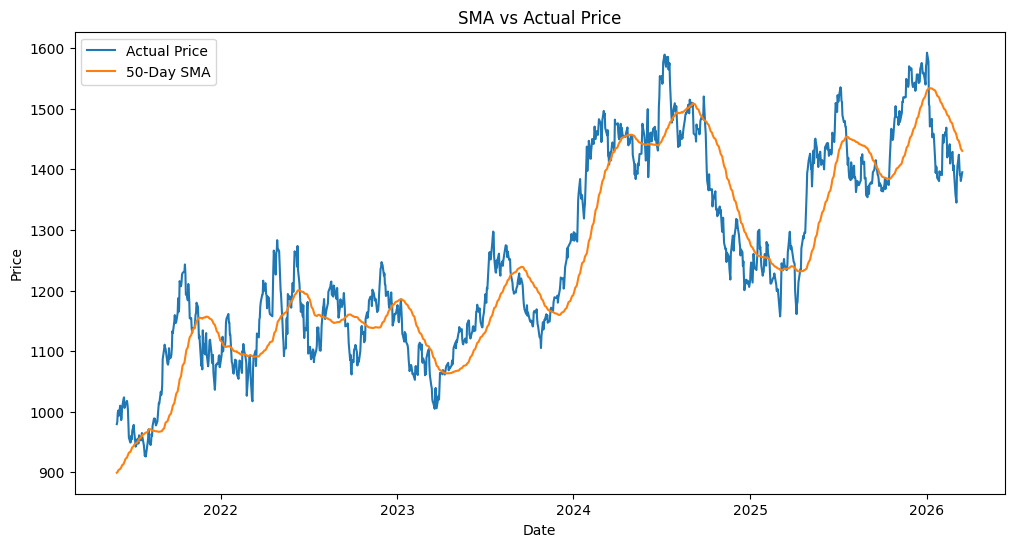

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Actual Price')
plt.plot(df.index, df['SMA'], label='50-Day SMA')
plt.title('SMA vs Actual Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

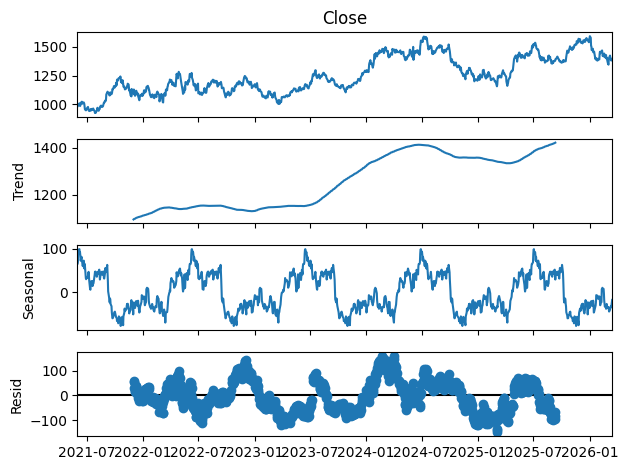

In [8]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=252)
decomposition.plot()
plt.show()

In [9]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA', 'Error', 'Percentage'], dtype='object', name='Price')

In [10]:
adf_res = adfuller(df['Close'])
adf_res[1]

np.float64(0.22075537542667478)

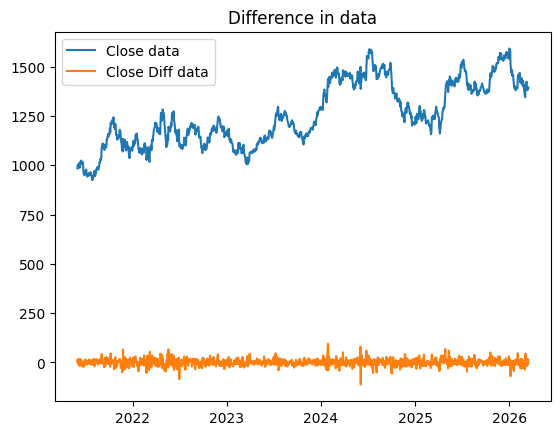

(None, 0.0)

In [11]:
df["Close_Diff"] = df["Close"].diff()
df.dropna(inplace=True)
adf_res_new = adfuller(df['Close_Diff'])
# adf_res_new[1]
plt.plot(df.index, df["Close"], label="Close data")
plt.plot(df.index, df["Close_Diff"], label="Close Diff data")
plt.title("Difference in data")
plt.legend()
plt.show(), adf_res_new[1]

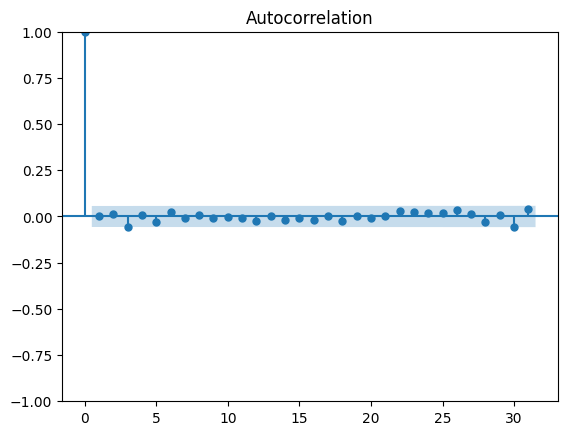

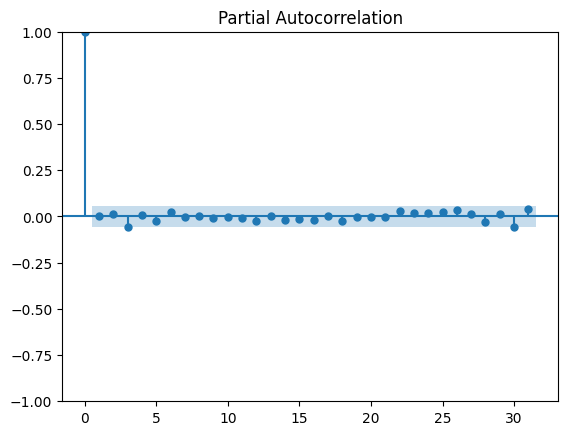

In [12]:
plot_acf(df['Close_Diff'])
plot_pacf(df['Close_Diff'])
plt.show()

Model Development

In [13]:
model = ARIMA(df['Close'], order=(1, 3, 3))
fitted_model = model.fit()
fitted_model.summary()

C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starti

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1187
Model:                 ARIMA(1, 3, 3)   Log Likelihood               -5078.937
Date:                Mon, 16 Mar 2026   AIC                          10167.873
Time:                        20:34:57   BIC                          10193.256
Sample:                             0   HQIC                         10177.441
                               - 1187                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9997      0.036    -27.765      0.000      -1.070      -0.929
ma.L1         -0.9992      0.364     -2.743      0.006      -1.713      -0.285
ma.L2         -1.0000      0.707     -1.414      0.157      -2.386       0.386
ma.L3          0.9992      0.350      2.852      0.004       0.312       1.686
sigma2       309.1735     97.765      3.162      0.002     117.558     500.789
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               633.91
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.91   Skew:                            -0.05
Prob(H) (two-sided):                  0.36   Kurtosis:                         6.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
future_prices = fitted_model.forecast(steps=5)
print(future_prices)

1187    1395.184851
1188    1395.416359
1189    1395.499561
1190    1395.729317
1191    1395.810845
Name: predicted_mean, dtype: float64


C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [15]:
new_df = df[:-108]
model1 = ARIMA(new_df['Close'], order=(0, 1, 0))
fitted_model1 = model1.fit()
# print(fitted_model1.summary())
future_prices_new = fitted_model1.forecast(steps=7)
future_prices_new.index = df.index[-107:-100]
print(future_prices_new)


Date
2025-10-10    1367.400024
2025-10-13    1367.400024
2025-10-14    1367.400024
2025-10-15    1367.400024
2025-10-16    1367.400024
2025-10-17    1367.400024
2025-10-20    1367.400024
Name: predicted_mean, dtype: float64


C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given wit

C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning

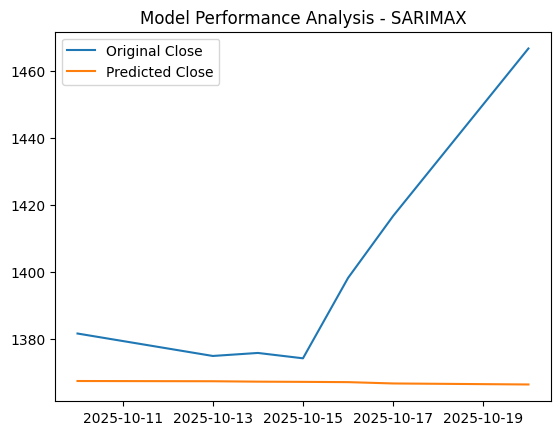

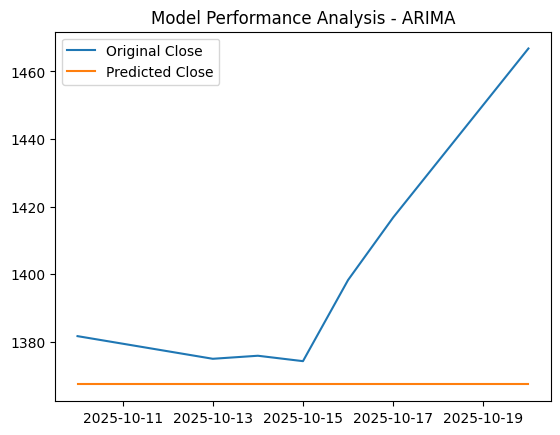

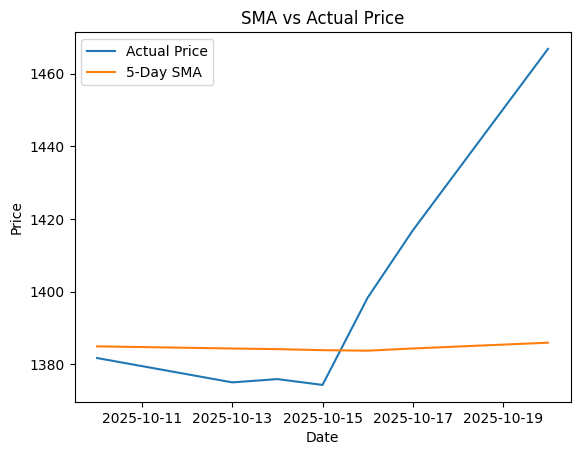

In [16]:
model_sarimax = SARIMAX(new_df['Close'], exog=new_df['Volume'], order=(0, 1, 0)).fit()
future_prices_sarimax = model_sarimax.forecast(steps=7, exog=df[-107:-100]['Volume'])
future_prices_sarimax.index = df.index[-107:-100]
plt.plot(df.index[-107:-100], df['Close'][-107:-100], label='Original Close')
plt.plot(df.index[-107:-100], future_prices_sarimax, label="Predicted Close")
plt.title("Model Performance Analysis - SARIMAX")
plt.legend()
plt.show()

plt.plot(df.index[-107:-100], df['Close'][-107:-100], label='Original Close')
plt.plot(df.index[-107:-100], future_prices_new, label="Predicted Close")
plt.title("Model Performance Analysis - ARIMA")
plt.legend()
plt.show()

plt.plot(df.index[-107:-100], df['Close'][-107:-100], label='Actual Price')
plt.plot(df.index[-107:-100], df['SMA'][-107:-100], label='5-Day SMA')
plt.title('SMA vs Actual Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

News Feed Ingestion

In [17]:
import feedparser
import pandas as pd
from transformers import pipeline

C:\Users\jayat\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
link = "https://news.google.com/rss/search?q=Reliance+Industries+stock&hl=en-IN&gl=IN&ceid=IN:en"
feed = feedparser.parse(link)
feed

{'bozo': False,
 'entries': [{'title': 'Reliance Industries shares trade lower after Trump announces $300 billion US refinery deal with oil giant - Upstox',
   'title_detail': {'type': 'text/plain',
    'language': None,
    'base': 'https://news.google.com/rss/search?q=Reliance+Industries+stock&hl=en-IN&gl=IN&ceid=IN:en',
    'value': 'Reliance Industries shares trade lower after Trump announces $300 billion US refinery deal with oil giant - Upstox'},
   'links': [{'rel': 'alternate',
     'type': 'text/html',
     'href': 'https://news.google.com/rss/articles/CBMi-gFBVV95cUxQQlhSTWJJYnZtNE91eUV2ODl2YjdIRmctWXFIMTJhV0FZTTBtTzgzZEdYN1hVcy15cGViZEo1V0kwZWZ2ZnRVQllSRXV2VTFsSE82aUpQdkVwR0t4Vk40dVlfN0U1RFZha1hZMkZ4eld5c0pLSFh1MDg0MC1YTHNocTNtWTlUR1BGdXBhUkNPX0VWaDdXRXJxYTUzWVYxR3BJd2ZtVk1KMVJMaHRMZjlBb3ZUXzRHcTBWMmR4czViV2JlblllWTFBUTEtV1MtX0tpcVMyelhFVWpJRTlPaG9WT0daODVyZHlCNDZrdDMxaFI0M3d2ZHFQV1N3?oc=5'}],
   'link': 'https://news.google.com/rss/articles/CBMi-gFBVV95cUxQQlhSTWJJYnZtNE91e

In [82]:
news = []
for item in feed.entries[:5000]:
    # print(item)
    date = item.published
    headline = item.title
    news.append({'published': pd.to_datetime(date).date(),
                 'headline': headline})
news_df = pd.DataFrame(news)
# news_df

Sentiment Analysis

In [83]:
sentiment_analyser = pipeline("sentiment-analysis", model="ProsusAI/finbert")

Device set to use cpu


In [84]:
results = sentiment_analyser(news_df['headline'].tolist())

news_df['label'] = [result['label'] for result in results]
news_df['score'] = [result['score'] for result in results]
news_df.head()

,published,headline,label,score
0,2026-03-11,Reliance Industries shares trade lower after T...,negative,0.948972
1,2026-03-16,Reliance Industries Ltd Sees High-Value Tradin...,positive,0.626381
2,2026-03-11,Why Reliance Industries shares are gaining in ...,positive,0.759048
3,2026-03-12,Reliance Industries Share Price Rises After Te...,neutral,0.395388
4,2026-03-16,"Reliance, Bharti Airtel, Larsen & Toubro: How ...",neutral,0.926888


In [85]:
news_df['sentiment_value'] = news_df['label'].str.lower().map({'positive': 1, 'neutral': 0, 'negative': -1})
news_df['adjusted_score'] = news_df['score'] * news_df['sentiment_value']
# news_df['daily_sentiment'] = news_df['adjusted_score'].groupby(news_df['published']).mean()
news_df.head()

,published,headline,label,score,sentiment_value,adjusted_score
0,2026-03-11,Reliance Industries shares trade lower after T...,negative,0.948972,-1,-0.948972
1,2026-03-16,Reliance Industries Ltd Sees High-Value Tradin...,positive,0.626381,1,0.626381
2,2026-03-11,Why Reliance Industries shares are gaining in ...,positive,0.759048,1,0.759048
3,2026-03-12,Reliance Industries Share Price Rises After Te...,neutral,0.395388,0,0.000000
4,2026-03-16,"Reliance, Bharti Airtel, Larsen & Toubro: How ...",neutral,0.926888,0,0.000000


In [86]:
daily_sentiment_df = news_df.groupby('published')['adjusted_score'].mean().reset_index()
daily_sentiment_df.head(10)

,published,adjusted_score
0,2025-07-21,-0.952743
1,2025-08-19,0.916222
2,2025-10-17,0.000000
3,2025-10-18,0.591862
4,2025-10-19,0.938015
5,2025-10-20,0.537785
6,2025-10-26,0.914067
7,2025-11-06,0.901365
8,2025-11-12,0.000000
9,2025-11-20,0.938426


Fusion Model - Data Preprocessing

In [87]:
df = df.reset_index()
df.head()

Price,level_0,index,Date,Close,High,Low,Open,Volume,SMA,Error,Percentage,Close_Diff
0,0,0,2021-06-01,983.447083,998.455648,973.290173,982.132103,28013832,900.033843,83.413240,0.084817,3.899536
1,1,1,2021-06-02,998.115601,1001.856408,978.051248,978.051248,24630162,901.356957,96.758644,0.096941,14.668518
2,2,2,2021-06-03,1001.924377,1020.220331,995.780410,1007.070776,23974257,903.175669,98.748708,0.098559,3.808777
3,3,3,2021-06-04,993.241211,1005.007723,990.407241,1004.259562,14468646,904.159614,89.081597,0.089688,-8.683167
4,4,4,2021-06-07,1009.972778,1016.592892,990.747319,998.455673,16336573,905.655938,104.316841,0.103287,16.731567


In [88]:
df['Date'] = pd.to_datetime(df['Date'])
daily_sentiment_df['published'] = pd.to_datetime(daily_sentiment_df['published'])
master_df = pd.merge(df, daily_sentiment_df, how='left', left_on='Date', right_on='published')
master_df['adjusted_score'] = master_df['adjusted_score'].fillna(0)
master_df.tail(15)

,level_0,index,Date,Close,High,Low,Open,Volume,SMA,Error,Percentage,Close_Diff,published,adjusted_score
1172,1172,1172,2026-02-23,1428.000000,1434.900024,1418.300049,1425.000000,7758856,1476.038000,-48.038000,0.033640,8.599976,NaT,0.000000
1173,1173,1173,2026-02-24,1428.800049,1433.300049,1415.000000,1425.300049,12529409,1473.484001,-44.683953,0.031274,0.800049,2026-02-24,0.000000
1174,1174,1174,2026-02-25,1398.500000,1440.500000,1393.500000,1435.000000,10728792,1470.330002,-71.830002,0.051362,-30.300049,NaT,0.000000
1175,1175,1175,2026-02-26,1406.800049,1412.900024,1391.900024,1398.500000,16683858,1467.620002,-60.819954,0.043233,8.300049,2026-02-26,-0.969962
1176,1176,1176,2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440,1464.610002,-70.709978,0.050728,-12.900024,NaT,0.000000
1177,1177,1177,2026-03-02,1358.000000,1378.599976,1341.500000,1375.500000,23728722,1460.882002,-102.882002,0.075760,-35.900024,NaT,0.000000
1178,1178,1178,2026-03-04,1345.000000,1352.800049,1307.000000,1330.000000,32495007,1456.480002,-111.480002,0.082885,-13.000000,NaT,0.000000
1179,1179,1179,2026-03-05,1389.400024,1399.000000,1353.099976,1353.099976,25957532,1452.760002,-63.359978,0.045602,44.400024,2026-03-05,0.171508
1180,1180,1180,2026-03-06,1404.800049,1424.300049,1390.300049,1396.500000,19311971,1449.442004,-44.641956,0.031778,15.400024,2026-03-06,0.874872
1181,1181,1181,2026-03-09,1424.000000,1429.400024,1370.000000,1375.000000,24870822,1446.758005,-22.758005,0.015982,19.199951,2026-03-09,0.587501


In [89]:
master_df['Target'] = master_df['Close'].shift(-1)
tomorrow_features = master_df.iloc[-1:]
master_df = master_df.dropna()
master_df.tail(15)

,level_0,index,Date,Close,High,Low,Open,Volume,SMA,Error,Percentage,Close_Diff,published,adjusted_score,Target
1149,1149,1149,2026-01-20,1394.000000,1416.000000,1390.000000,1410.699951,13189498,1527.922004,-133.922004,0.096070,-19.599976,2026-01-20,-0.709718,1404.599976
1150,1150,1150,2026-01-21,1404.599976,1412.900024,1373.000000,1389.500000,17352720,1526.146003,-121.546028,0.086534,10.599976,2026-01-21,-0.353965,1402.500000
1157,1157,1157,2026-02-02,1390.400024,1392.900024,1335.500000,1340.000000,15711165,1508.058000,-117.657976,0.084622,-5.000000,2026-02-02,0.724460,1437.099976
1160,1160,1160,2026-02-05,1443.400024,1461.500000,1439.500000,1457.000000,11763658,1502.360002,-58.959978,0.040848,-13.400024,2026-02-05,-0.822527,1450.800049
1170,1170,1170,2026-02-19,1409.500000,1443.000000,1400.000000,1443.000000,11884664,1480.728000,-71.228000,0.050534,-31.800049,2026-02-19,0.746299,1419.400024
1171,1171,1171,2026-02-20,1419.400024,1427.400024,1406.099976,1409.500000,8177670,1478.378000,-58.977976,0.041551,9.900024,2026-02-20,0.734828,1428.000000
1173,1173,1173,2026-02-24,1428.800049,1433.300049,1415.000000,1425.300049,12529409,1473.484001,-44.683953,0.031274,0.800049,2026-02-24,0.000000,1398.500000
1175,1175,1175,2026-02-26,1406.800049,1412.900024,1391.900024,1398.500000,16683858,1467.620002,-60.819954,0.043233,8.300049,2026-02-26,-0.969962,1393.900024
1179,1179,1179,2026-03-05,1389.400024,1399.000000,1353.099976,1353.099976,25957532,1452.760002,-63.359978,0.045602,44.400024,2026-03-05,0.171508,1404.800049
1180,1180,1180,2026-03-06,1404.800049,1424.300049,1390.300049,1396.500000,19311971,1449.442004,-44.641956,0.031778,15.400024,2026-03-06,0.874872,1424.000000


In [90]:
features = ['Volume', 'SMA', 'Error', 'adjusted_score']
X = master_df[features]
y = master_df['Target']
X.tail(10), y.tail(10)

(        Volume          SMA      Error  adjusted_score
 1171   8177670  1478.378000 -58.977976        0.734828
 1173  12529409  1473.484001 -44.683953        0.000000
 1175  16683858  1467.620002 -60.819954       -0.969962
 1179  25957532  1452.760002 -63.359978        0.171508
 1180  19311971  1449.442004 -44.641956        0.874872
 1181  24870822  1446.758005 -22.758005        0.587501
 1182  18071259  1443.750007 -34.949958       -0.969860
 1183  21848087  1440.642007 -50.442056       -0.094962
 1184  20939959  1437.690005 -45.490054        0.460547
 1185  17265090  1433.896003 -53.196052        0.306978,
 1171    1428.000000
 1173    1398.500000
 1175    1393.900024
 1179    1404.800049
 1180    1424.000000
 1181    1408.800049
 1182    1390.199951
 1183    1392.199951
 1184    1380.699951
 1185    1395.099976
 Name: Target, dtype: float64)

In [91]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

len(X_train), len(X_test), len(X)

(29, 8, 37)

In [92]:
X

,Volume,SMA,Error,adjusted_score
1024,22442744,1453.148279,-30.231287,-0.952743
1044,14384719,1440.358884,-20.258909,0.916222
1085,19335561,1384.335725,32.464324,0.000000
1086,24721978,1385.926536,80.873513,0.537785
1097,16772678,1405.280007,90.819968,0.901365
1101,12384459,1413.912009,97.587991,0.000000
1107,18171724,1432.506011,116.593965,0.938426
1110,15033482,1442.220010,97.479941,0.915676
1113,8959508,1452.244009,115.255991,0.308990
1115,11389150,1457.916008,88.384041,-0.962348


Fusion Model - Model

In [93]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [94]:
model = XGBRegressor(n_estimators=1000, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [95]:
predictions = model.predict(X_test)
predictions

array([1413.5532, 1400.8857, 1420.8245, 1422.1671, 1409.8666, 1396.8322,
       1405.7642, 1403.4501], dtype=float32)

In [96]:
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Error: 12.2279052734375


In [97]:
live_features = tomorrow_features[['Volume', 'SMA', 'Error', 'adjusted_score']]

In [98]:
tomorrow_prediction = model.predict(live_features)
print(f"Predicted Reliance Close Price for Tomorrow: ₹{tomorrow_prediction[0]:.2f}")

Predicted Reliance Close Price for Tomorrow: ₹1400.89
